In [4]:
import numpy as np
import matplotlib.pyplot as plt
import glob

from astropy.io import fits

In [23]:
def plot_selected_channel(data, start_ch=None, end_ch=None, tittle=None, grid=50, save_name=None):#data_shape=(depth, width, height)
    plt.figure(figsize=(6, 6))
    mean_data = np.nanmean(data, axis=(1, 2))
    
    plt.plot(np.arange(len(mean_data)), mean_data, "k")
    plt.xlabel("Channel")
    plt.xticks(np.arange(0, len(mean_data), grid), fontsize=8)
    plt.ylabel("Mean Intensity [K]")

    if start_ch is not None:
        plt.axvline(x=start_ch, color='red', linestyle='--', label=f'channel = {start_ch}')
    if end_ch is not None:
        plt.axvline(x=end_ch, color='b', linestyle='--', label=f'channel = {end_ch}')

    plt.grid()
    plt.legend()
    plt.title(str(tittle), fontsize=14)

    if save_name is not None:
        plt.savefig(save_name)

    plt.show()

In [24]:
fits_path_all = glob.glob("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/*12CO*.fits")
fits_path_all.sort()

In [25]:
print(fits_path_all[20])

/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_03100+0000_2x2_12CO_v1.00_cube.fits


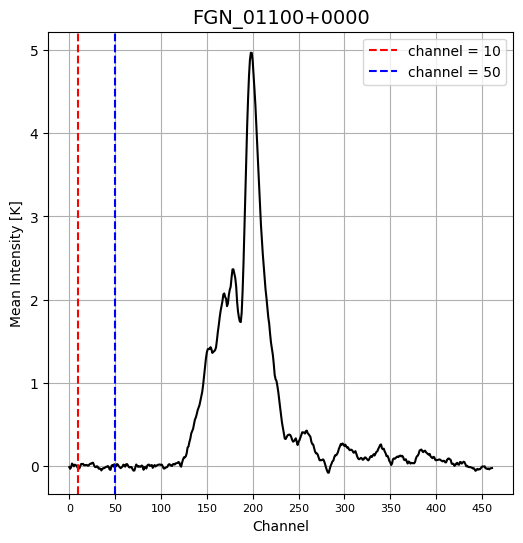

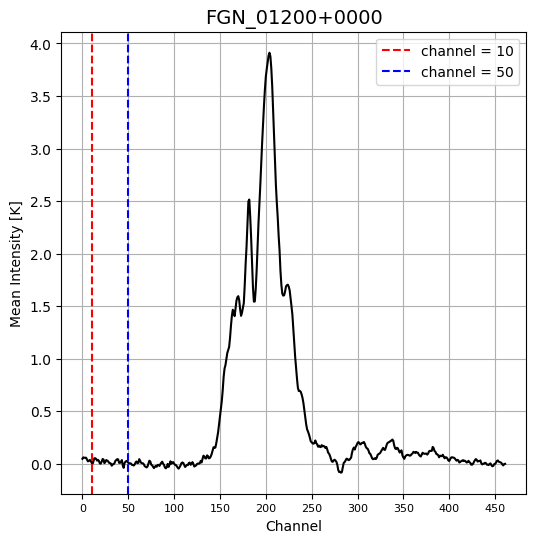

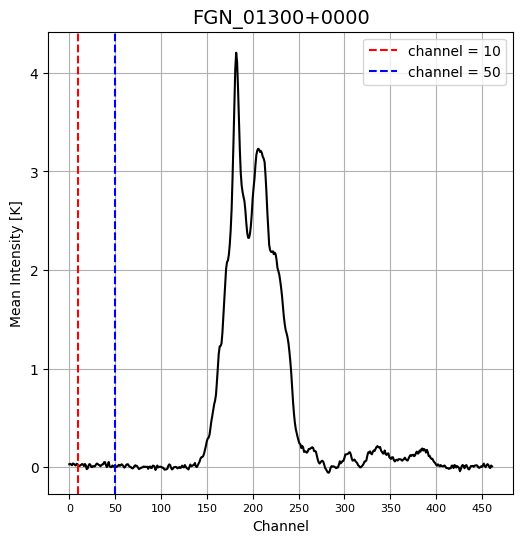

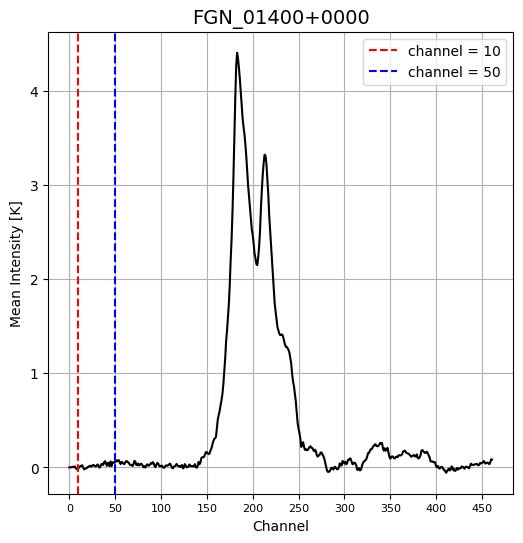

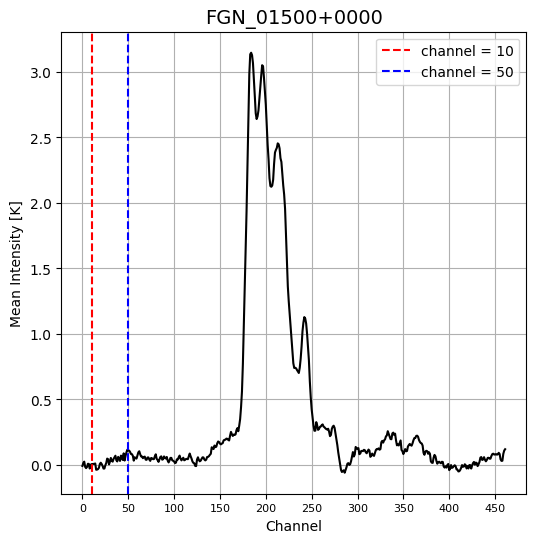

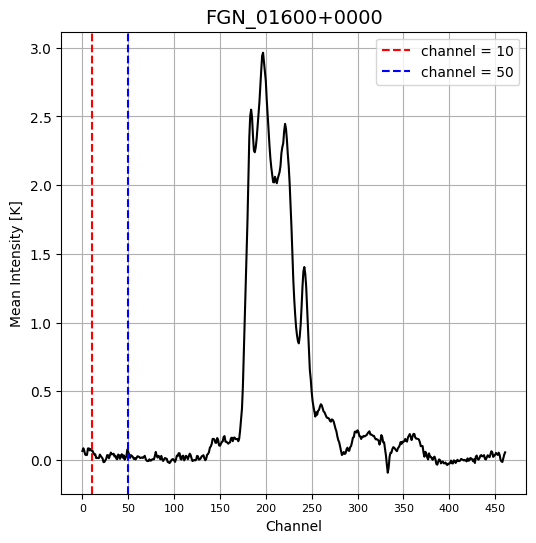

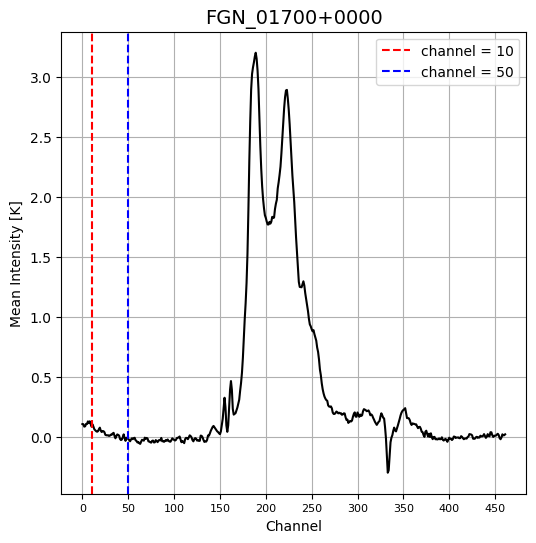

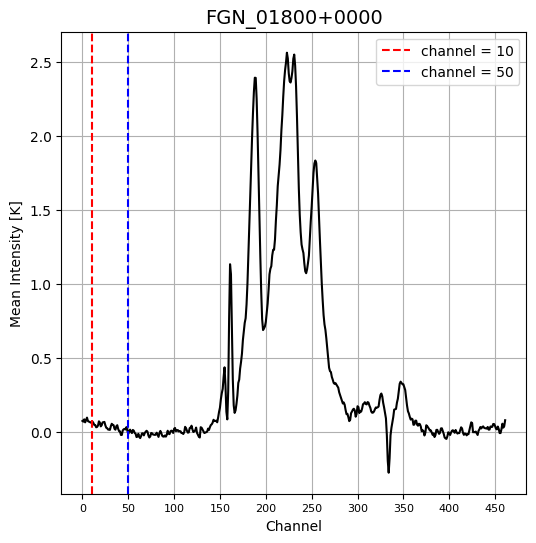

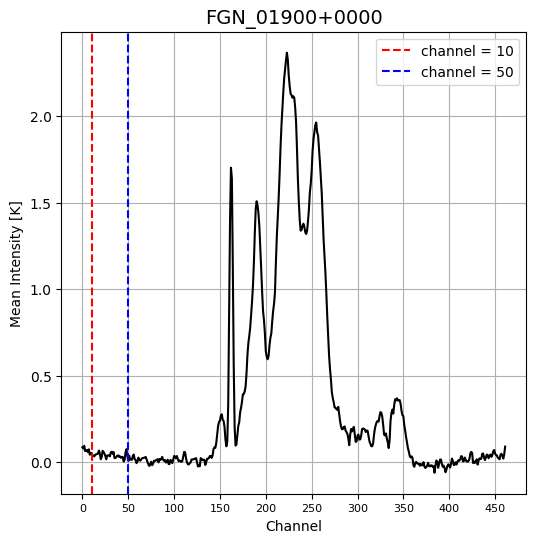

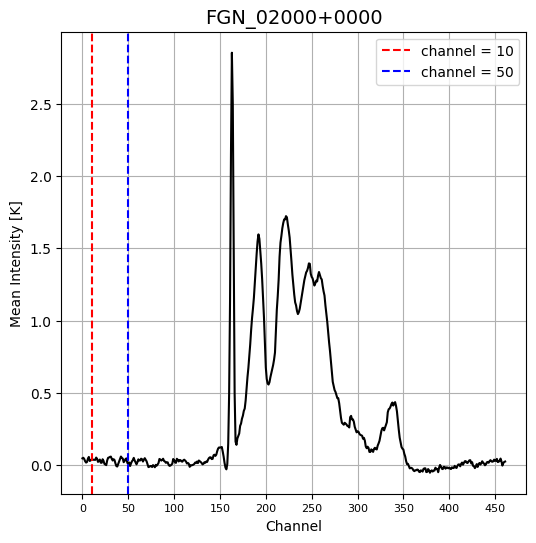

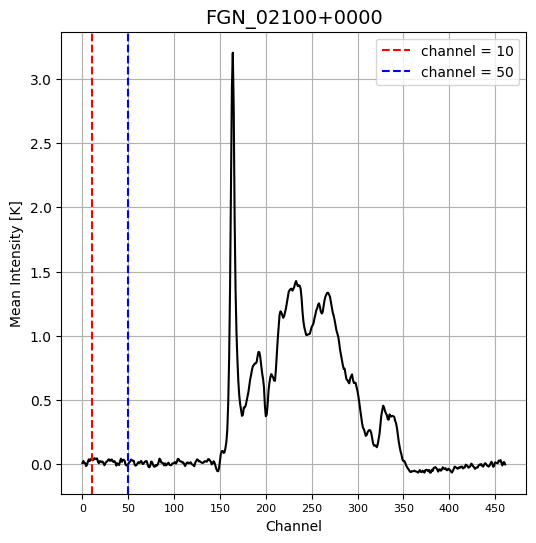

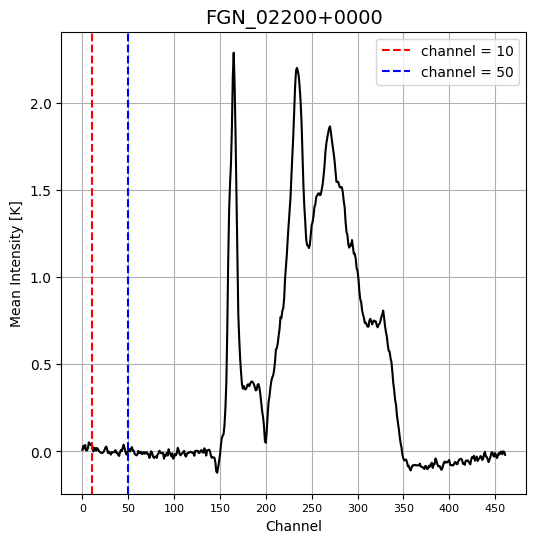

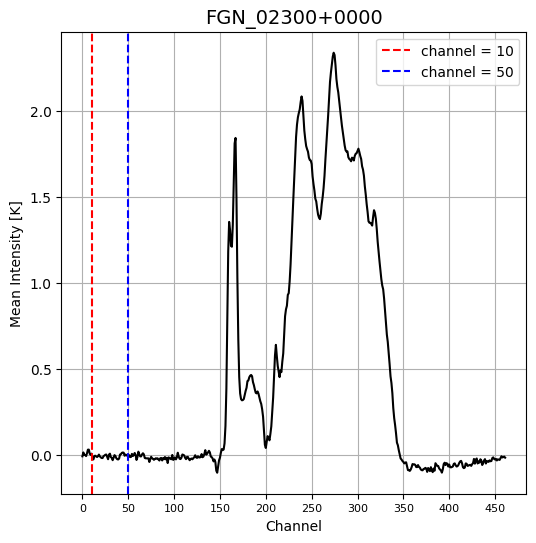

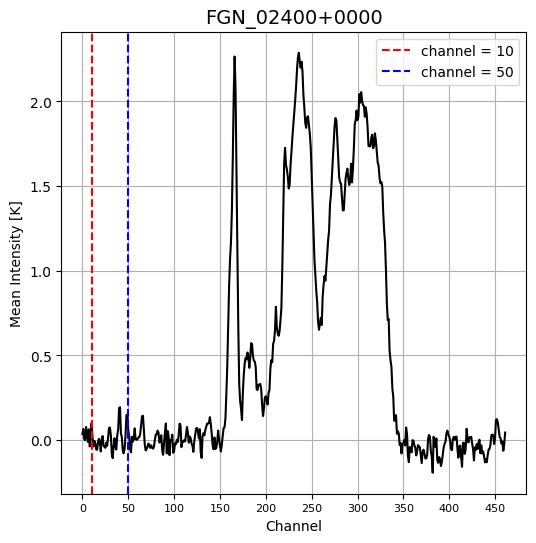

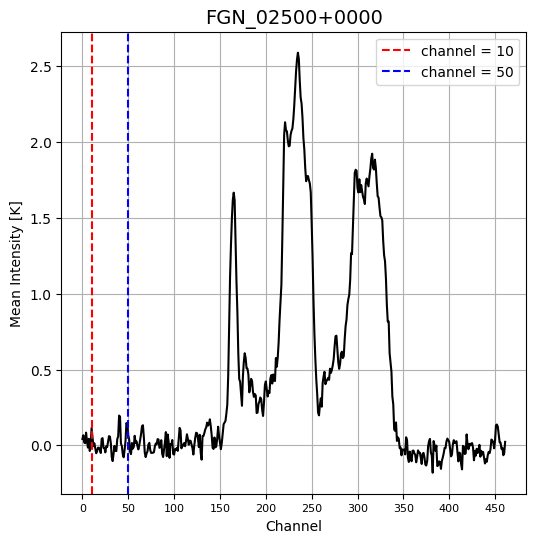

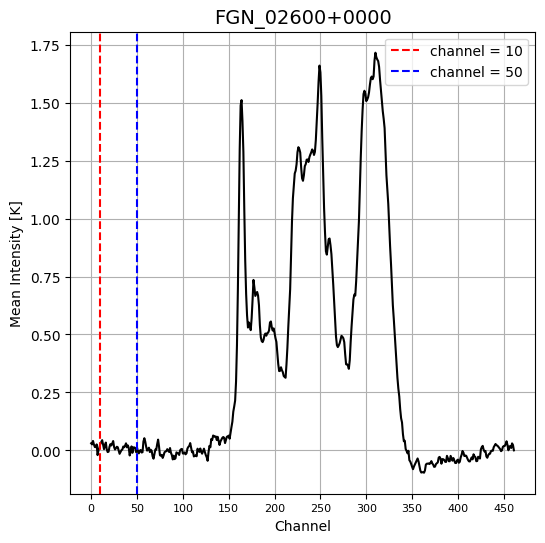

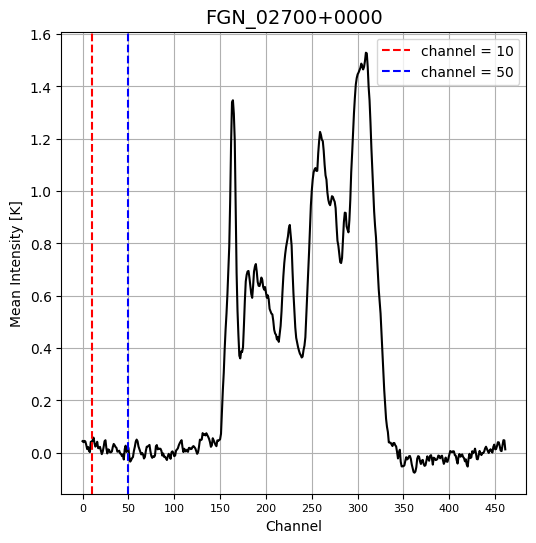

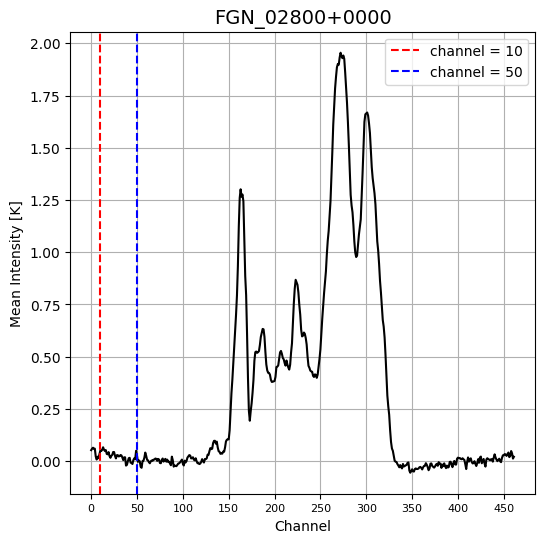

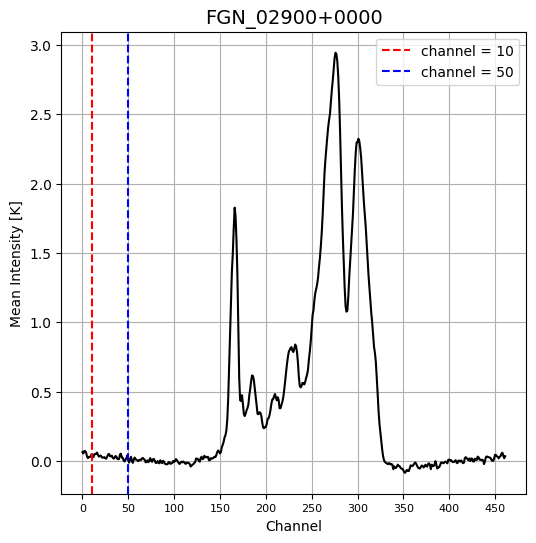

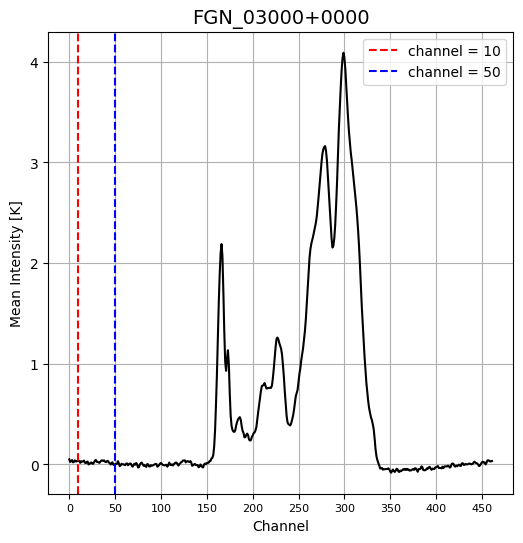

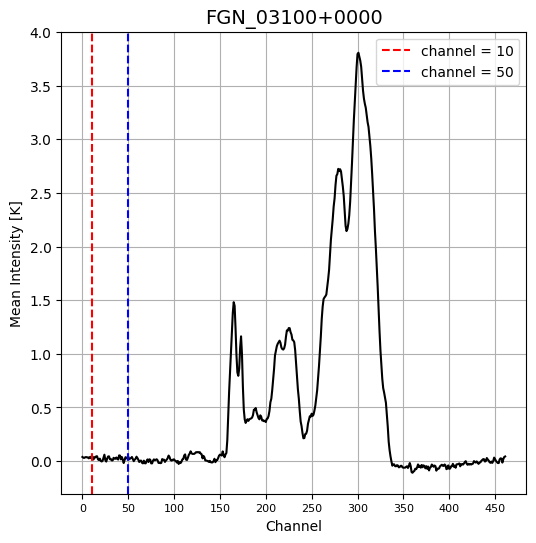

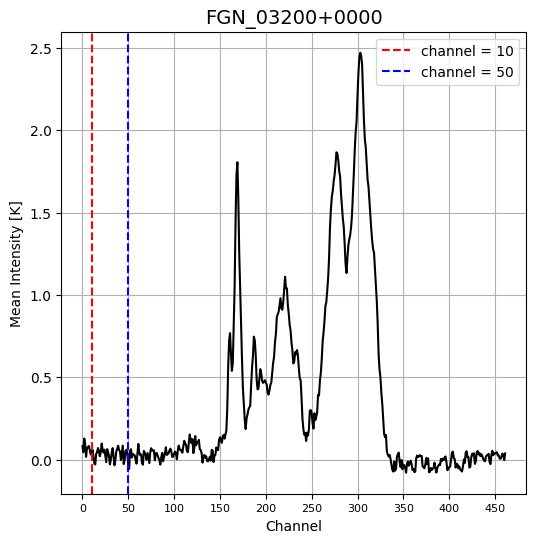

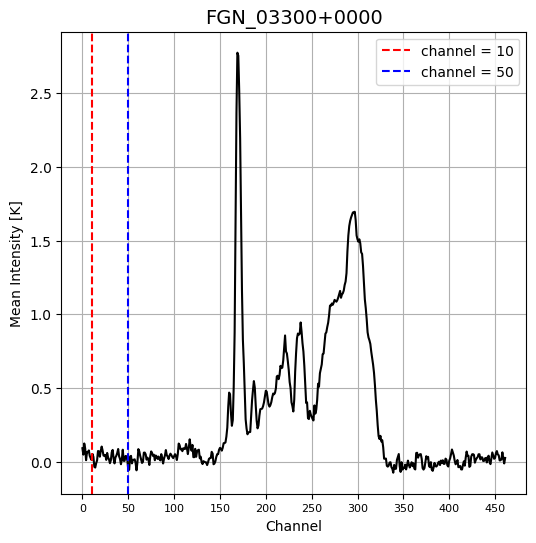

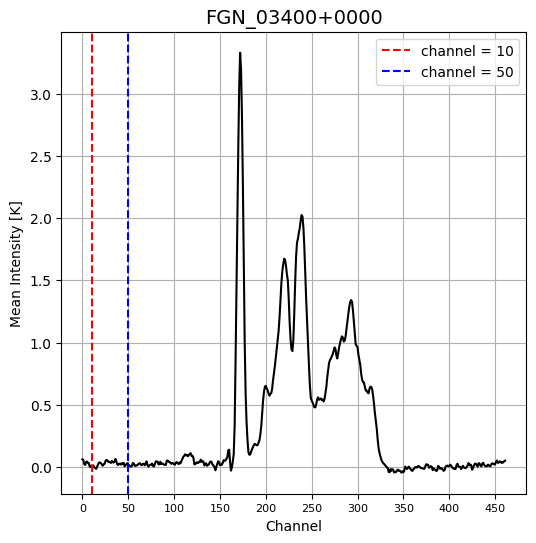

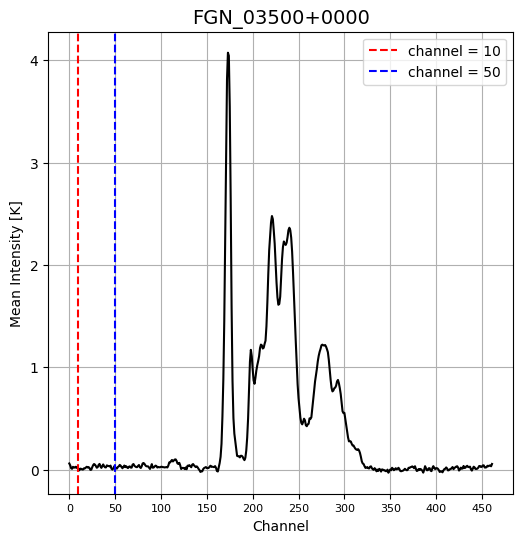

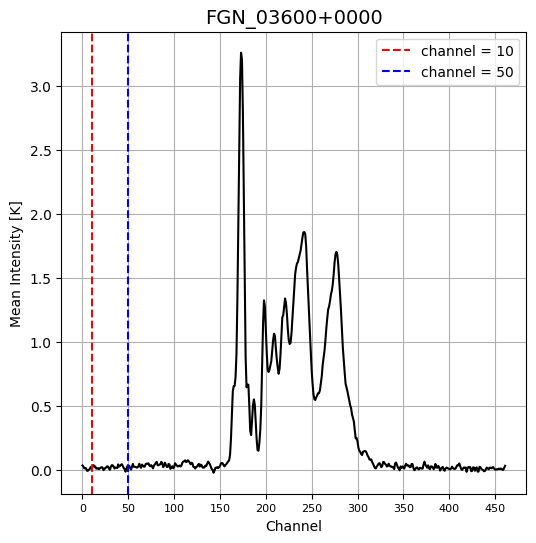

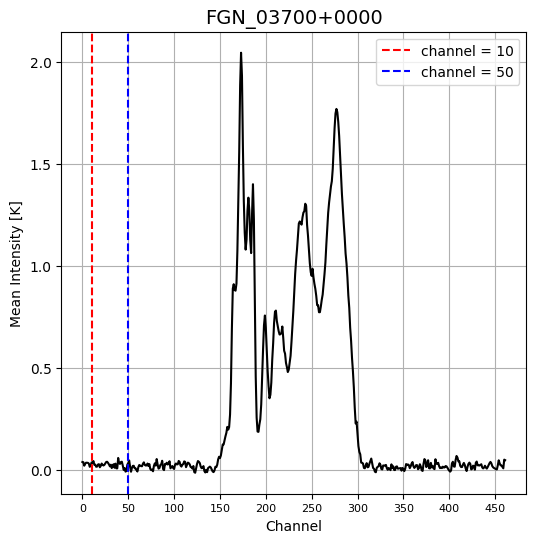

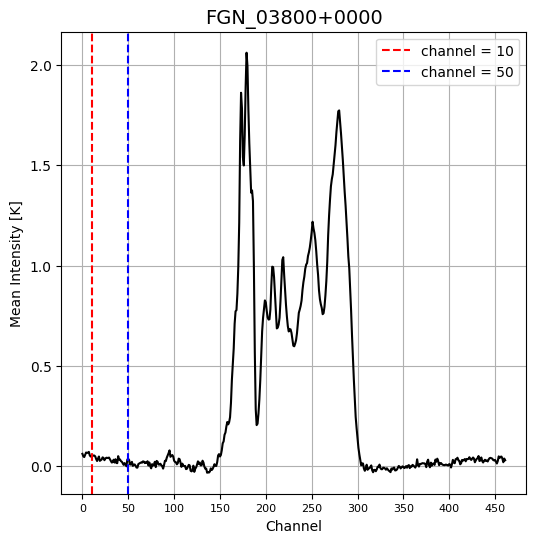

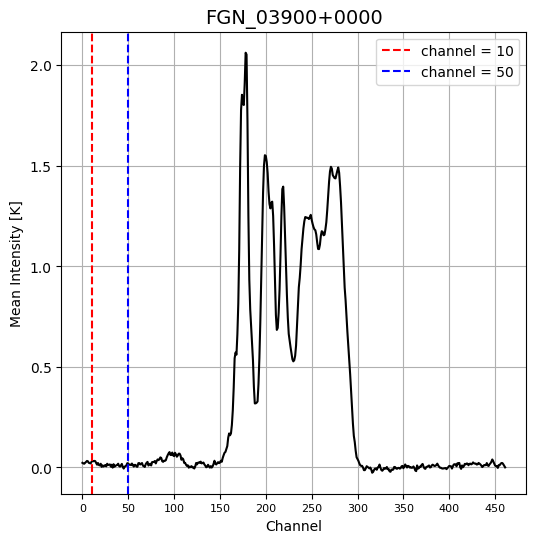

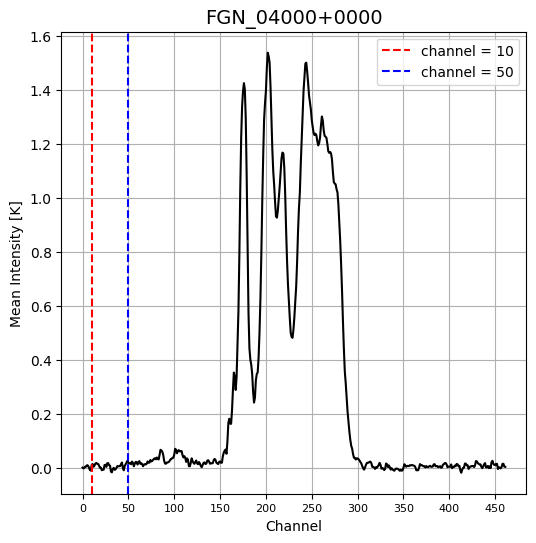

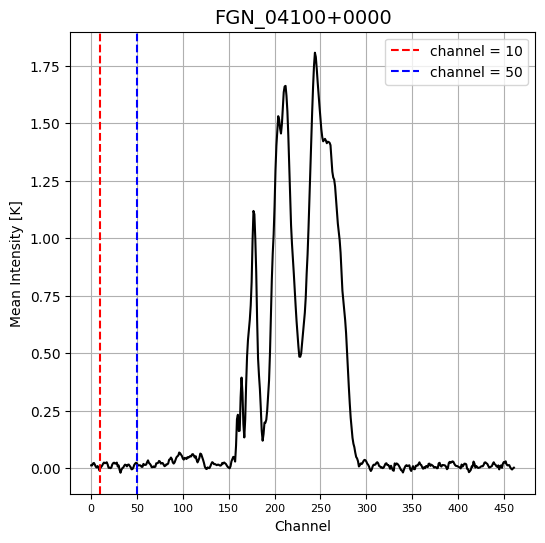

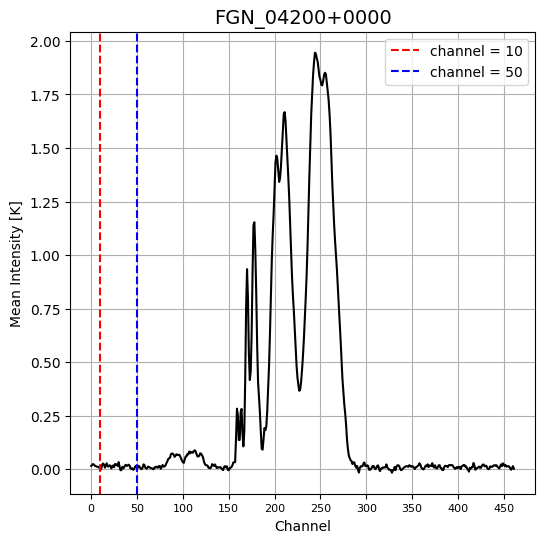

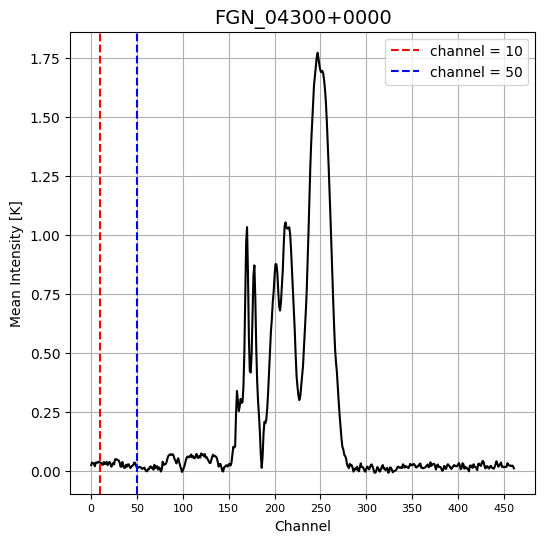

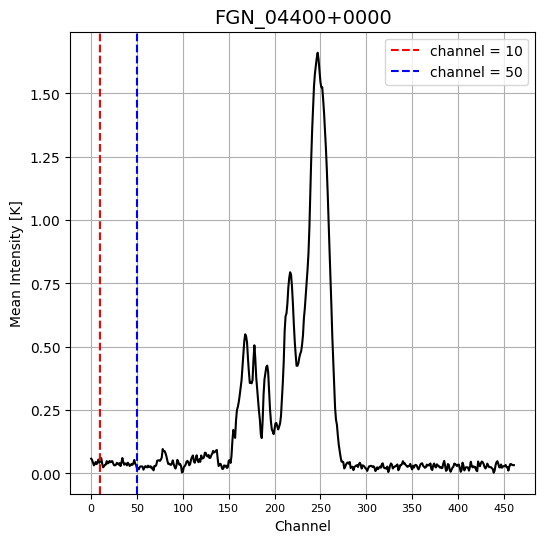

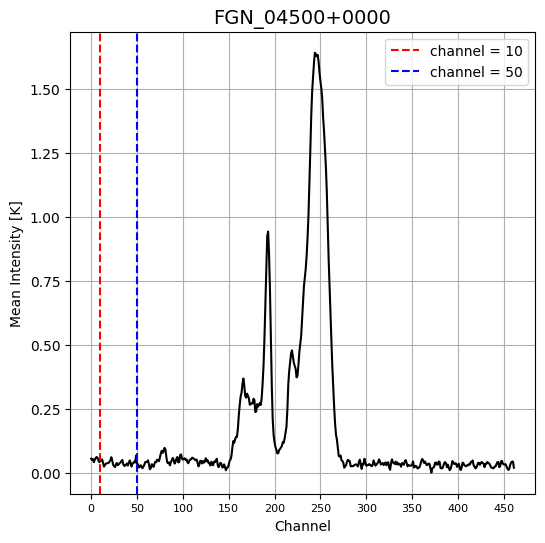

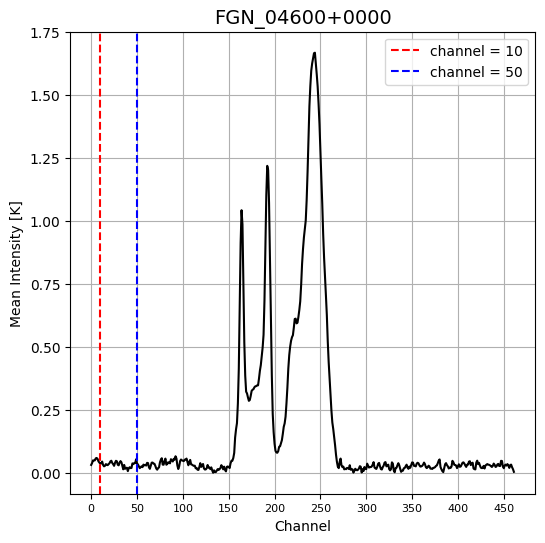

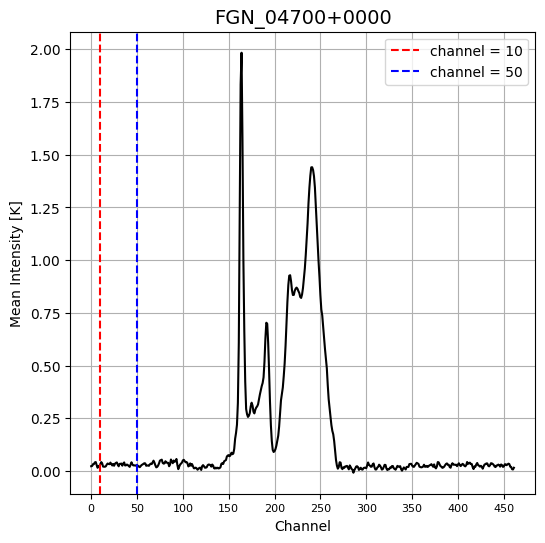

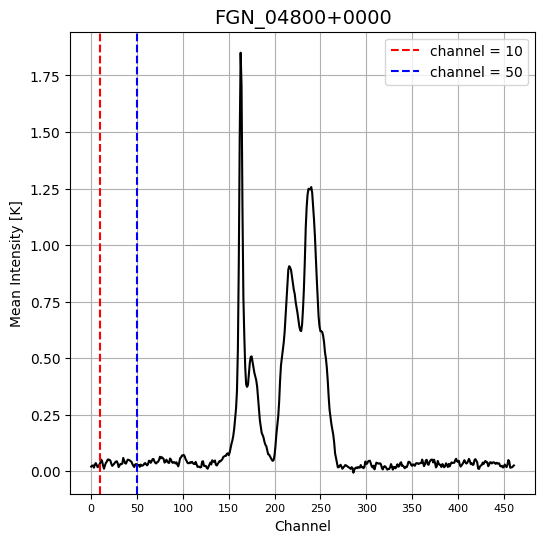

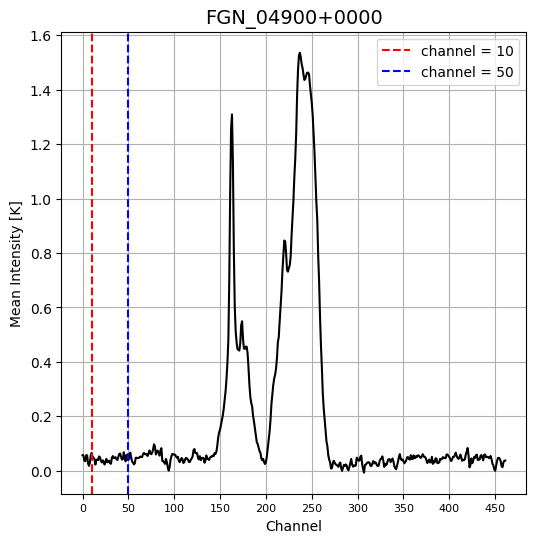

In [28]:
for path in fits_path_all:
    hdu = fits.open(path)[0]
    data = hdu.data
    name = path.split('/')[-1].split('_2')[0]
    save_name = f"mean_spectrum/{name}"
    plot_selected_channel(data, 10, 50, name, 50, save_name)